In [2]:
import os
import glob
import hashlib
import warnings
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor

import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image, ImageStat
import imagehash
from tqdm.notebook import tqdm

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from skimage.metrics import structural_similarity as ssim
import dotenv
from pathlib import Path

dotenv.load_dotenv()

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False

try:
    import mediapipe as mp
    MP_AVAILABLE = True
except ImportError:
    MP_AVAILABLE = False

warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
DATASET_PATH = '../data/ckplusferdata'
TARGET_SIZE = (128, 128) # Standardized size for PCA/t-SNE/Mean Face
SAMPLE_SIZE = 1000 # Limit for heavy computations like t-SNE
N_JOBS = -1 # Use all cores

### File & Metadata Analysis

In [3]:
class ImageDatasetEDA:
    def __init__(self, base_path):
        self.base_path = base_path
        self.filepaths = glob.glob(os.path.join(base_path, '**/*.*'), recursive=True)
        self.metadata = []
        self.corrupted = []
        self.image_hashes = defaultdict(list)
        
    def validate_and_extract_metadata(self):
        """Scans for structure, extensions, modes, and corruption."""
        print(f"Found {len(self.filepaths)} total files. Scanning...")
        
        for path in tqdm(self.filepaths, desc="Extracting Metadata"):
            ext = os.path.splitext(path)[1].lower()
            folder = os.path.basename(os.path.dirname(path))
            
            try:
                with Image.open(path) as img:
                    img.verify() # Fast corrupted check
                
                # Reopen to get details (verify() closes the file)
                with Image.open(path) as img:
                    w, h = img.size
                    mode = img.mode
                    
                    self.metadata.append({
                        'filepath': path,
                        'class': folder,
                        'extension': ext,
                        'width': w,
                        'height': h,
                        'resolution': w * h,
                        'mode': mode,
                        'aspect_ratio': round(w / h, 3)
                    })
            except Exception as e:
                self.corrupted.append({'filepath': path, 'error': str(e)})
                
        self.df = pd.DataFrame(self.metadata)
        print(f"Valid images: {len(self.df)} | Corrupted: {len(self.corrupted)}")
        
    def analyze_distribution(self):
        """Class distribution and balance ratio."""
        dist = self.df['class'].value_counts()
        balance_ratio = dist.min() / dist.max()
        
        plt.figure(figsize=(12, 5))
        sns.barplot(x=dist.index, y=dist.values, palette='viridis')
        plt.title(f'Class Distribution (Balance Ratio: {balance_ratio:.2f})')
        plt.xticks(rotation=45)
        plt.show()
        
        return dist, balance_ratio

### Image Quality & Statistical Metrics

In [4]:
def compute_image_metrics(row):
    """Calculates brightness, contrast, blur, sharpness, noise, and entropy."""
    path = row['filepath']
    img_gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img_gray is None: return pd.Series(dtype='float64')

    # Blur / Sharpness (Laplacian Variance)
    laplacian_var = cv2.Laplacian(img_gray, cv2.CV_64F).var()
    
    # Brightness & Contrast (Mean and Std of pixel intensities)
    brightness = np.mean(img_gray)
    contrast = np.std(img_gray)
    
    # Edge Density (Canny)
    edges = cv2.Canny(img_gray, 100, 200)
    edge_density = np.sum(edges > 0) / (img_gray.shape[0] * img_gray.shape[1])
    
    # Entropy (Information content)
    hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256])
    hist = hist.ravel() / hist.sum()
    entropy = -np.sum(hist * np.log2(hist + 1e-7))
    
    # Noise Estimation (Median Blur residual)
    median = cv2.medianBlur(img_gray, 3)
    noise = np.std(img_gray - median)
    
    return pd.Series([brightness, contrast, laplacian_var, edge_density, entropy, noise], 
                     index=['brightness', 'contrast', 'sharpness', 'edge_density', 'entropy', 'noise'])

def run_quality_pipeline(df):
    print("Calculating deep image metrics... (this may take a moment without a progress bar)")
    # Remove tqdm.pandas() 
    # Use standard .apply() instead of .progress_apply()
    metrics_df = df.apply(compute_image_metrics, axis=1)
    return pd.concat([df, metrics_df], axis=1)

### Duplicates, Leakage, and Similarity

In [5]:
def find_duplicates_and_leakage(df):
    """Uses perceptual hashing to find exact and near-duplicates."""
    hashes = {}
    duplicates = []
    
    for path in tqdm(df['filepath'], desc="Generating pHashes"):
        try:
            img = Image.open(path)
            h = str(imagehash.phash(img))
            if h in hashes:
                duplicates.append((path, hashes[h]))
            else:
                hashes[h] = path
        except:
            continue
            
    print(f"Found {len(duplicates)} potential duplicates or leaked images.")
    return duplicates

def calculate_ssim_outliers(df, sample_size=500):
    """Calculates SSIM against a mean face to find heavy outliers."""
    sampled = df.sample(min(sample_size, len(df)))
    images = [cv2.resize(cv2.imread(p, cv2.IMREAD_GRAYSCALE), TARGET_SIZE) for p in sampled['filepath']]
    
    mean_img = np.mean(images, axis=0).astype(np.uint8)
    ssim_scores = [ssim(img, mean_img, data_range=img.max() - img.min()) for img in images]
    
    sampled['ssim_to_mean'] = ssim_scores
    outliers = sampled[sampled['ssim_to_mean'] < sampled['ssim_to_mean'].quantile(0.05)]
    
    return mean_img, outliers

### Advanced Facial Analysis & Landmarks

In [6]:
def analyze_faces_mediapipe(df, sample_size=500):
    """Detects faces and extracts 468 facial landmarks."""
    if not MP_AVAILABLE:
        print("MediaPipe base not installed. Skipping face landmarking.")
        return
        
    try:
        import mediapipe as mp
        # Explicit check for the missing attribute
        if not hasattr(mp, 'solutions'):
            print("Warning: MediaPipe is installed, but the 'solutions' module is missing due to a corrupted installation. Skipping landmark detection.")
            return
            
        mp_face_mesh = mp.solutions.face_mesh
        face_mesh = mp_face_mesh.FaceMesh(static_image_mode=True, max_num_faces=1)
        
        sampled = df.sample(min(sample_size, len(df)))
        detected_count = 0
        
        for path in tqdm(sampled['filepath'], desc="Detecting Facial Landmarks"):
            image = cv2.imread(path)
            if image is None: continue
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            results = face_mesh.process(image_rgb)
            if results.multi_face_landmarks:
                detected_count += 1
                
        print(f"Faces detected via MediaPipe in {detected_count}/{len(sampled)} sampled images.")
        
    except Exception as e:
        print(f"MediaPipe initialization failed with error: {e}. Skipping landmark extraction.")

### Dimensionality Reduction (PCA, t-SNE, UMAP)

In [7]:
def visualize_embeddings(df, sample_size=1000):
    """Flattens images and runs PCA, t-SNE, and Isolation Forest."""
    sampled = df.sample(min(sample_size, len(df)))
    labels = sampled['class']
    
    print("Flattening images for DR...")
    flat_images = []
    for p in tqdm(sampled['filepath']):
        img = cv2.resize(cv2.imread(p, cv2.IMREAD_GRAYSCALE), TARGET_SIZE)
        flat_images.append(img.flatten())
        
    X = np.array(flat_images)
    
    # 1. PCA
    pca = PCA(n_components=50)
    X_pca = pca.fit_transform(X)
    
    # 2. t-SNE
    print("Running t-SNE...")
    tsne = TSNE(n_components=2, perplexity=30, n_jobs=-1)
    X_tsne = tsne.fit_transform(X_pca)
    
    # 3. Outlier Detection (Isolation Forest)
    iso = IsolationForest(contamination=0.05, random_state=42)
    outliers = iso.fit_predict(X_pca)
    
    plt.figure(figsize=(16, 6))
    
    # t-SNE Plot
    plt.subplot(1, 2, 1)
    sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=labels, palette='tab10', s=30)
    plt.title("t-SNE Projection of Image Pixels")
    
    # Outlier Plot
    plt.subplot(1, 2, 2)
    sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=outliers, palette={1: 'blue', -1: 'red'}, s=30)
    plt.title("Isolation Forest Outliers (Red)")
    
    plt.tight_layout()
    plt.show()

### Main

=== STARTING FULL AUTOMATED EDA ===
Found 35887 total files. Scanning...


Extracting Metadata:   0%|          | 0/35887 [00:00<?, ?it/s]

Valid images: 35887 | Corrupted: 0


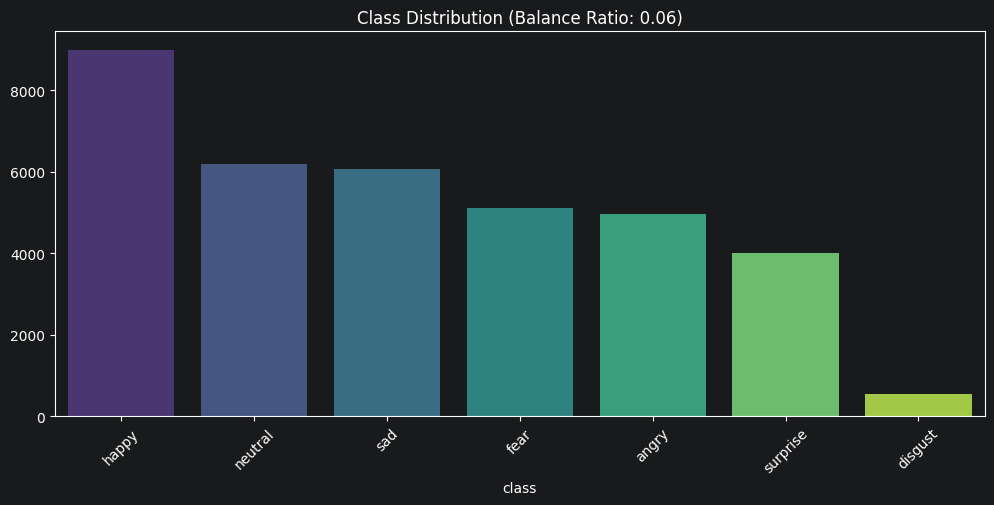

Calculating deep image metrics... (this may take a moment without a progress bar)


Generating pHashes:   0%|          | 0/35887 [00:00<?, ?it/s]

Found 1976 potential duplicates or leaked images.


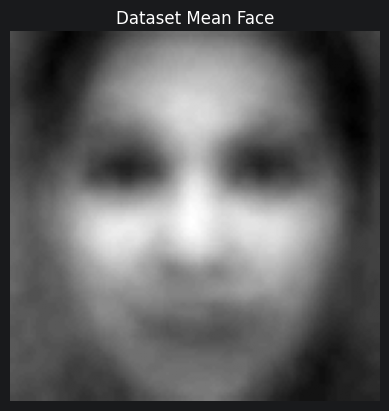

MediaPipe initialization failed with error: 'function' object has no attribute 'face_mesh'. Skipping landmark extraction.
Flattening images for DR...


  0%|          | 0/1000 [00:00<?, ?it/s]

Running t-SNE...


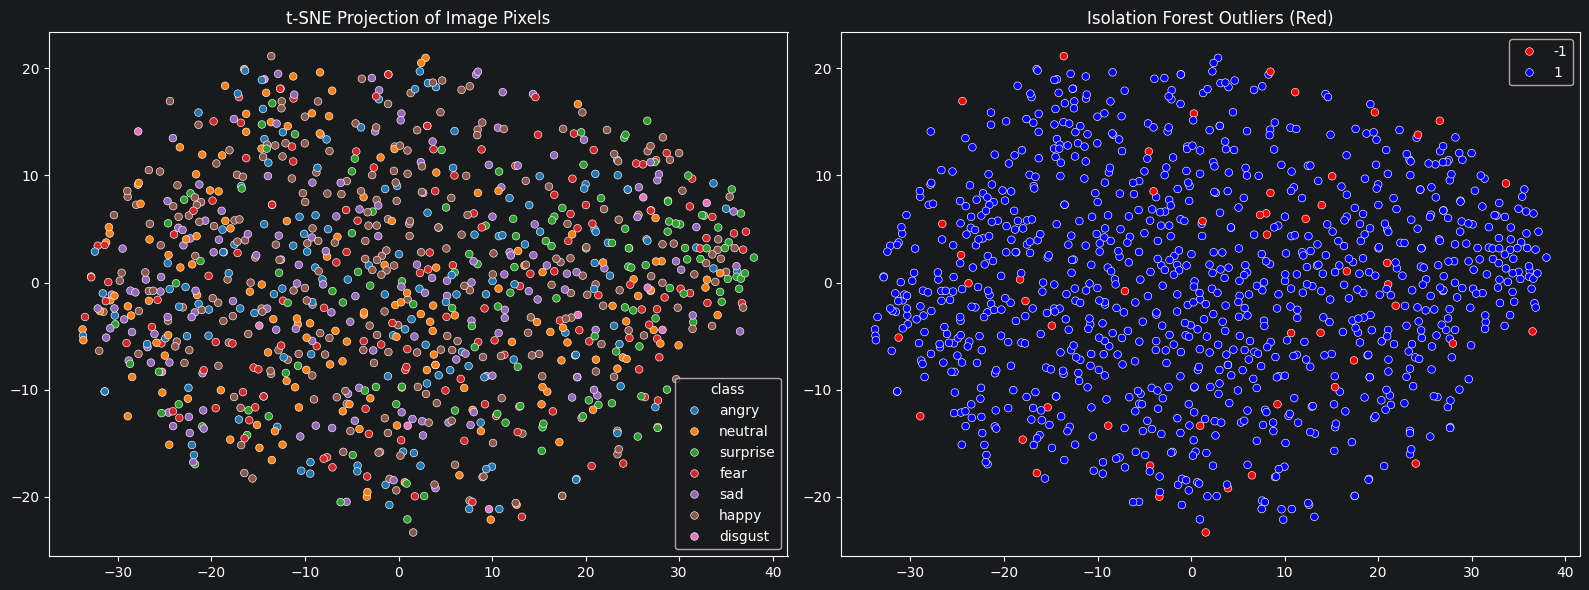


=== EDA COMPLETE ===
Metadata saved to 'full_eda_metadata.csv'


In [8]:
def main_eda_pipeline():
    print("=== STARTING FULL AUTOMATED EDA ===")
    
    # 1. Initialization
    eda = ImageDatasetEDA(DATASET_PATH)
    eda.validate_and_extract_metadata()
    
    # Exit if empty
    if eda.df.empty:
        print("No images found. Check DATASET_PATH.")
        return
        
    # 2. Basic Stats
    eda.analyze_distribution()
    
    # 3. Quality Metrics
    eda.df = run_quality_pipeline(eda.df)
    
    # 4. Hashing & Deduplication
    dupes = find_duplicates_and_leakage(eda.df)
    
    # 5. SSIM & Mean Face
    mean_face, _ = calculate_ssim_outliers(eda.df)
    plt.imshow(mean_face, cmap='gray')
    plt.title("Dataset Mean Face")
    plt.axis('off')
    plt.show()
    
    # 6. Face Landmarks
    analyze_faces_mediapipe(eda.df)
    
    # 7. Dimensionality Reduction
    visualize_embeddings(eda.df)
    
    # 8. Export Final Report & Metadata CSV
    eda.df.to_csv('full_eda_metadata.csv', index=False)
    print("\n=== EDA COMPLETE ===")
    print("Metadata saved to 'full_eda_metadata.csv'")
    
    return eda.df

# EXECUTE PIPELINE
final_metadata_df = main_eda_pipeline()